### 4. Test-Training-Split und Imputation

#### 1. Verbindung zur Datenbank - view öffnen

In [ ]:
import json
import urllib.parse  # Neu: Zum Kodieren des Passworts
from sqlalchemy import create_engine
import pandas as pd

# 1. Konfiguration laden
with open('db_config.json', 'r') as f:
    config = json.load(f)

# 2. Passwort kodieren (Löst den UnicodeDecodeError '0xfc' / 'ü')
# Das sorgt dafür, dass Sonderzeichen im Passwort URL-konform sind
safe_password = urllib.parse.quote_plus(config['DB_PASSWORD'])

# 3. Verbindung herstellen (mit dem sicheren Passwort)
engine = create_engine(
    f"postgresql://{config['DB_USER']}:{safe_password}@{config['DB_HOST']}:{config['DB_PORT']}/{config['DB_NAME']}"
)

# 4. Deine neue VIEW abfragen
# Hier setzen wir den Namen deiner erstellten View ein
query = "SELECT * FROM vw_airbnb_model_data" 

try:
    df = pd.read_sql(query, engine)
    print(f"✅ Erfolg! {len(df)} Zeilen aus der View '{query.split()[-1]}' geladen.")
    
    # Kurzer Check der Daten
    print(df.head()) 
    
except Exception as e:
    print(f"❌ Fehler beim Laden: {e}")
finally:
    engine.dispose()

✅ Erfolg! 20974 Zeilen aus der View 'vw_airbnb_model_data' geladen.
         id neighbourhood_group_cleansed        room_type  instant_bookable  \
0  40824219                       Queens     Private room             False   
1  40839416                    Manhattan     Private room             False   
2  40843980                       Queens  Entire home/apt             False   
3  40824301                     Brooklyn     Private room             False   
4  40825740                     Brooklyn  Entire home/apt             False   

   accommodates  bathrooms  bedrooms  beds  host_total_listings_count  \
0             1        1.0       1.0   1.0                        3.0   
1             1        2.0       1.0   1.0                       16.0   
2             6        1.0       2.0   3.0                        2.0   
3             1        1.0       2.0   1.0                        1.0   
4             6        4.0       3.0   3.0                        9.0   

   distance_to_cen

#### 2. Test/train Split

In [3]:
from sklearn.model_selection import train_test_split

# Features und Target trennen
# Wir löschen 'id' und 'price', da wir 'ln_price' vorhersagen wollen
X = df.drop(['id', 'price', 'ln_price'], axis=1)
y = df['ln_price']

# 80% Training, 20% Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training-Set: {X_train.shape[0]} Zeilen")
print(f"Test-Set: {X_test.shape[0]} Zeilen")

Training-Set: 16779 Zeilen
Test-Set: 4195 Zeilen


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20974 entries, 0 to 20973
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            20974 non-null  int64  
 1   neighbourhood_group_cleansed  20974 non-null  object 
 2   room_type                     20974 non-null  object 
 3   instant_bookable              20974 non-null  bool   
 4   accommodates                  20974 non-null  int64  
 5   bathrooms                     20967 non-null  float64
 6   bedrooms                      20888 non-null  float64
 7   beds                          20933 non-null  float64
 8   host_total_listings_count     19935 non-null  float64
 9   distance_to_center            20974 non-null  float64
 10  price                         20974 non-null  float64
 11  ln_price                      20974 non-null  float64
dtypes: bool(1), float64(7), int64(2), object(2)
memory usage: 1.

#### 3. Imputation der fehlenden Werte

In [9]:
import numpy as np

# 1. host_total_listings_count
X_train['host_total_listings_count'] = X_train['host_total_listings_count'].fillna(0)
X_test['host_total_listings_count'] = X_test['host_total_listings_count'].fillna(0)

# 2. Bathrooms (Modus vom Training berechnen!)
bath_mode = X_train['bathrooms'].mode()[0]
X_train['bathrooms'] = X_train['bathrooms'].fillna(bath_mode)
X_test['bathrooms'] = X_test['bathrooms'].fillna(bath_mode)

# 3. Bedrooms (Logik: aufgerundete Hälfte von accommodates)
X_train['bedrooms'] = X_train['bedrooms'].fillna(np.ceil(X_train['accommodates'] / 2))
X_test['bedrooms'] = X_test['bedrooms'].fillna(np.ceil(X_test['accommodates'] / 2))

# 4. Beds (Logik: aufgerundete Hälfte von accommodates)
X_train['beds'] = X_train['beds'].fillna(np.ceil(X_train['accommodates'] / 2))
X_test['beds'] = X_test['beds'].fillna(np.ceil(X_test['accommodates'] / 2))

# Kontroll-Check
print("Fehlwerte in X_train:")
print(X_train[['host_total_listings_count', 'bathrooms', 'bedrooms', 'beds']].isna().sum())

Fehlwerte in X_train:
host_total_listings_count    0
bathrooms                    0
bedrooms                     0
beds                         0
dtype: int64


#### 4. VIF-Check

In [12]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Wir wählen die numerischen Spalten aus, die wir prüfen wollen
vif_cols = ['accommodates', 'bathrooms', 'bedrooms', 'beds', 'host_total_listings_count', 'distance_to_center']
X_vif = X_train[vif_cols]

# VIF berechnen
vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]

print(vif_data.sort_values(by="VIF", ascending=False))

                     feature       VIF
3                       beds  7.385461
0               accommodates  6.994108
1                  bathrooms  5.175159
2                   bedrooms  5.079712
5         distance_to_center  2.479413
4  host_total_listings_count  1.061621


**Interpretation VIF:**   
Das ist ein hervorragendes Ergebnis für reale Daten! Deine VIF-Werte liegen fast alle im Bereich um 5 bis 7.

In der Statistik sagt man oft:

    VIF < 5: Keine Multikollinearität (Idealfall).

    VIF 5 bis 10: Moderate Multikollinearität (Akzeptabel).

    VIF > 10: Starke Multikollinearität (Handlungsbedarf).

"Wackelkandidaten" sind beds (7.38) und accommodates (6.99). Das ist völlig logisch: Mehr Gäste bedeuten fast immer mehr Betten. Da sie aber beide unter 10 liegen, könntest du sie theoretisch beide im Modell lassen.

**Entscheidung:** Trotz moderater Korrelation zwischen Betten und Kapazität (VIF < 10) wurden beide Variablen beibehalten, da sie unterschiedliche Aspekte der Wohnungsqualität abbilden.

#### 5. OHE: neighbourhood_group_cleansed, room_type, instant_bookable

In [14]:
# Wir wandeln die Kategorien in 0/1-Spalten um
# drop_first=True verhindert die "Dummy Variable Trap" (nochmal VIF-Schutz!)
X_train_final = pd.get_dummies(X_train, columns=['neighbourhood_group_cleansed', 'room_type', 'instant_bookable'], drop_first=True)
X_test_final = pd.get_dummies(X_test, columns=['neighbourhood_group_cleansed', 'room_type', 'instant_bookable'], drop_first=True)

# Sicherstellen, dass Train und Test die gleichen Spalten haben (falls ein Stadtteil im Test-Set fehlt)
X_train_final, X_test_final = X_train_final.align(X_test_final, join='left', axis=1, fill_value=0)

print(f"Finale Anzahl der Features: {X_train_final.shape[1]}")

Finale Anzahl der Features: 15


#### 6. Lineare Regression: Modell trainieren

In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# 1. Modell initialisieren und fitten
model = LinearRegression()
model.fit(X_train_final, y_train)

# 2. Vorhersagen erstellen
y_pred_train = model.predict(X_train_final)
y_pred_test = model.predict(X_test_final)

# 3. Gütemaße berechnen
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

print(f"R² (Training): {r2_train:.4f}")
print(f"R² (Test):     {r2_test:.4f}")
print(f"RMSE (Test):   {rmse_test:.4f} (in log-Einheiten)")

R² (Training): 0.5312
R² (Test):     0.5187
RMSE (Test):   0.5398 (in log-Einheiten)


#### 7. Visualisierungen

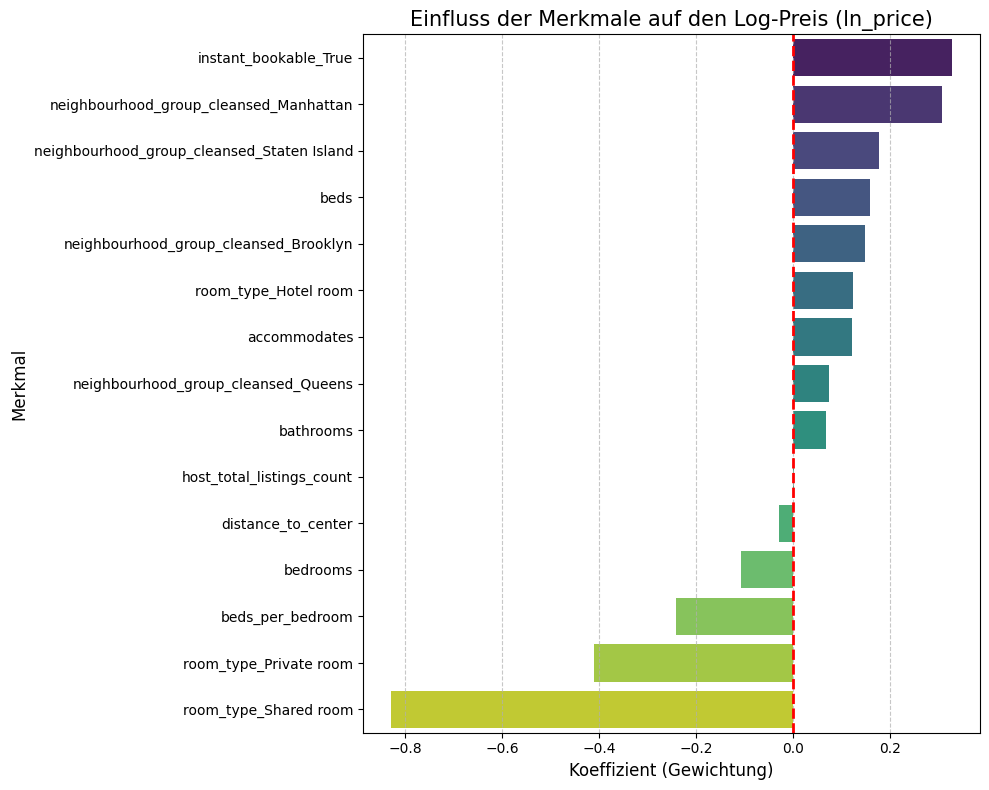

Top 5 Preistreiber:
                                       Feature    Weight
14                       instant_bookable_True  0.326712
8       neighbourhood_group_cleansed_Manhattan  0.305754
10  neighbourhood_group_cleansed_Staten Island  0.175506
3                                         beds  0.157762
7        neighbourhood_group_cleansed_Brooklyn  0.146659

Top 5 Preissenker:
                   Feature    Weight
5       distance_to_center -0.029826
2                 bedrooms -0.108014
6         beds_per_bedroom -0.241974
12  room_type_Private room -0.412106
13   room_type_Shared room -0.829933


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Koeffizienten extrahieren
coef_df = pd.DataFrame({'Feature': X_train_final.columns, 'Weight': model.coef_})
coef_df = coef_df.sort_values(by='Weight', ascending=False)

# Visualisierung
plt.figure(figsize=(10, 8))
sns.barplot(x='Weight', y='Feature', data=coef_df, hue='Feature', palette='viridis', legend=False)
plt.title('Einfluss der Merkmale auf den Log-Preis (ln_price)', fontsize=15)
plt.xlabel('Koeffizient (Gewichtung)', fontsize=12)
plt.ylabel('Merkmal', fontsize=12)
plt.axvline(0, color='red', lw=2, linestyle='--')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Die Top 5 Gewinner und Verlierer anzeigen
print("Top 5 Preistreiber:")
print(coef_df.head(5))
print("\nTop 5 Preissenker:")
print(coef_df.tail(5))